# 02 - K-Means clustering of driving windows

Goal: take the per-second telemetry, aggregate it into short windows that
represent a snippet of driving, and ask whether these snippets fall into
a small number of recognisable behavioral clusters.

Plan:

1. Build a `(n_windows x n_features)` table using `src.features` (5-second
   windows, six summary statistics per sensor).
2. Look at the feature distributions and pairwise structure (PCA, 2-D
   projection coloured by driver).
3. Run KMeans for `k=2..12` and pick `k` from elbow + silhouette curves.
4. Profile each cluster: mean sensor values and per-driver composition.

We are **not** claiming the clusters are "safe vs dangerous" - the dataset
has no risk labels. The clusters are *behavioral modes* (e.g. cruising,
heavy braking, urban stop-and-go) that the model finds in the data.


In [1]:
import sys, os
from pathlib import Path

# Make the project root importable so that `import src` works no matter where
# Jupyter was launched from.
HERE = Path(os.getcwd()).resolve()
ROOT = HERE if (HERE / "src").is_dir() else HERE.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("project root:", ROOT)


project root: C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.io import load_cleaned
from src.features import build_window_feature_table, feature_columns, BEHAVIOR_SENSORS

sns.set_theme(style="whitegrid")
RNG = 42


## 1. Build the window feature table

In [3]:
df = load_cleaned()
print("rows:", len(df), "drivers:", sorted(df["driver_id"].unique()))

windows = build_window_feature_table(df, window_size=5, sensors=BEHAVIOR_SENSORS)
print("windows:", len(windows), "/ features:", len(feature_columns(windows)))
windows.head()


rows: 94380 drivers: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


C:\Users\moham\Desktop\Projects\Driver_assessment_classification_model\src\features.py:57: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  vskew = float(skew(values, bias=False))


windows: 4997 / features: 60


,driver_id,window_id,global_window_id,n_rows,vehicle_speed__mean,vehicle_speed__std,vehicle_speed__min,vehicle_speed__max,vehicle_speed__range,vehicle_speed__skew,...,steering_wheel_angle__min,steering_wheel_angle__max,steering_wheel_angle__range,steering_wheel_angle__skew,fuel_consumption__mean,fuel_consumption__std,fuel_consumption__min,fuel_consumption__max,fuel_consumption__range,fuel_consumption__skew
0,A,0,A_w0,16,0.00,0.000000,0.0,0.0,0.0,0.000000,...,-3.6,3.0,6.6,-0.256454,388.80,223.261640,204.8,921.6,716.8,1.425955
1,A,1,A_w1,20,0.00,0.000000,0.0,0.0,0.0,0.000000,...,-3.6,89.7,93.3,4.327355,281.60,62.313787,192.0,422.4,230.4,0.554733
2,A,2,A_w2,20,1.45,2.801339,0.0,9.0,9.0,1.919527,...,-7.3,372.3,379.6,1.265590,495.36,196.641497,294.4,934.4,640.0,1.447801
3,A,3,A_w3,20,4.35,4.777813,0.0,13.0,13.0,0.882128,...,-245.4,488.0,733.4,0.948533,577.92,225.049882,422.4,1292.8,870.4,2.127451
4,A,4,A_w4,20,4.95,3.787809,0.0,11.0,11.0,-0.053760,...,-387.2,335.9,723.1,-0.105797,548.48,124.382481,422.4,896.0,473.6,1.955599


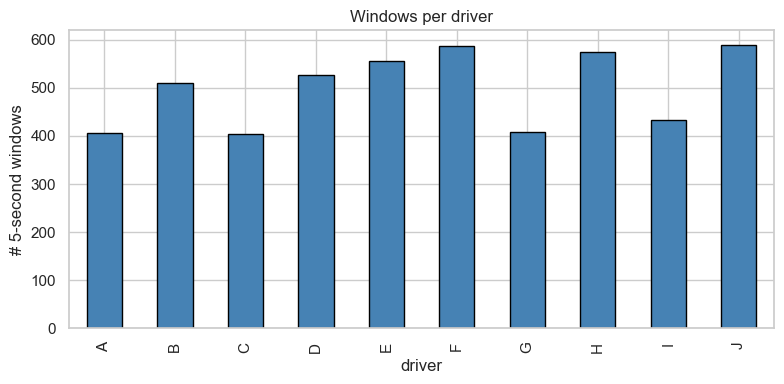

In [4]:
wins_per_driver = windows["driver_id"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
wins_per_driver.plot.bar(ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("driver"); ax.set_ylabel("# 5-second windows")
ax.set_title("Windows per driver"); plt.tight_layout(); plt.show()


## 2. Standardize and look at the feature space

We use `StandardScaler` because KMeans is distance-based and the raw
features have very different scales (RPM in thousands, lateral
acceleration in single digits).


In [5]:
feat_cols = feature_columns(windows)
X = windows[feat_cols].fillna(0.0).to_numpy()
y_driver = windows["driver_id"].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("X shape:", X_scaled.shape)


X shape: (4997, 60)


PC variance explained: [0.242 0.132]  total: 0.374


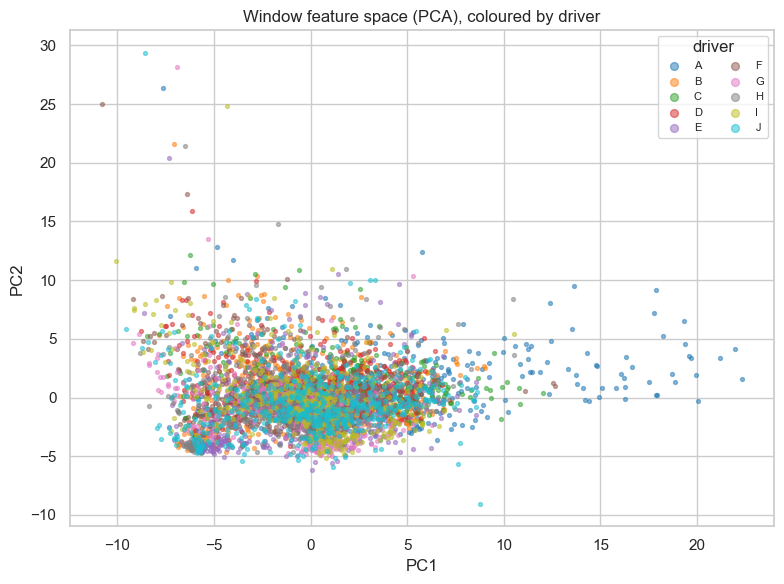

In [6]:
pca = PCA(n_components=2, random_state=RNG)
X_pca = pca.fit_transform(X_scaled)
print("PC variance explained:", pca.explained_variance_ratio_.round(3),
      " total:", round(pca.explained_variance_ratio_.sum(), 3))

fig, ax = plt.subplots(figsize=(8, 6))
drivers = sorted(np.unique(y_driver))
palette = sns.color_palette("tab10", len(drivers))
for col, d in zip(palette, drivers):
    m = y_driver == d
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.5, color=col, label=d)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Window feature space (PCA), coloured by driver")
ax.legend(title="driver", markerscale=2, ncol=2, fontsize=8)
plt.tight_layout(); plt.show()


The drivers overlap heavily in the principal-component plane, which
already tells us something important: there is no clean per-driver
clustering at the window level. The cluster structure we are about to
look for is therefore *behavioural*, not per-driver.


## 3. Choose `k` via elbow + silhouette

In [7]:
ks = range(2, 13)
inertias = []
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=RNG))

diag = pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes})
diag


,k,inertia,silhouette
0,2,257678.377890,0.141851
1,3,234065.325827,0.173638
2,4,217510.530033,0.115727
3,5,203069.365646,0.122591
4,6,190989.061809,0.130463
5,7,181744.904812,0.131660
6,8,174754.429248,0.102171
7,9,168799.579300,0.106283
8,10,163310.134894,0.108055
9,11,159195.626411,0.097002


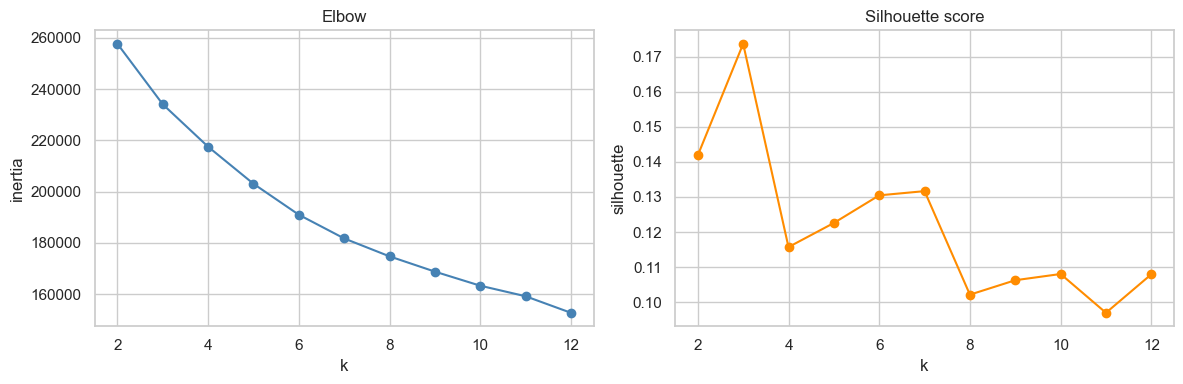

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(diag["k"], diag["inertia"], marker="o", color="steelblue")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow")
axes[1].plot(diag["k"], diag["silhouette"], marker="o", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
axes[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()


In [9]:
best_k = int(diag.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("best k by silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RNG)
windows["cluster"] = kmeans.fit_predict(X_scaled)
windows["cluster"].value_counts().sort_index()


best k by silhouette: 3


cluster
0     589
1    3079
2    1329
Name: count, dtype: int64

## 4. Project clusters onto PCA

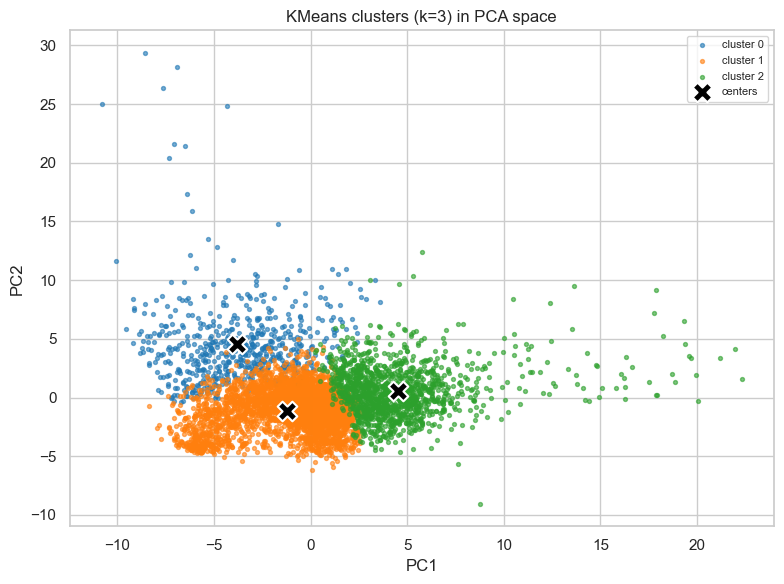

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("tab10", best_k)
for c in range(best_k):
    m = windows["cluster"].to_numpy() == c
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.6, color=palette[c], label=f"cluster {c}")
centers_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, c="black", marker="X",
           edgecolor="white", linewidth=1.5, label="centers")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"KMeans clusters (k={best_k}) in PCA space")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Profile each cluster

For each cluster we look at the mean of a few interpretable per-window
features. This is what lets us describe a cluster in plain language
(e.g. "high-speed cruising", "city stop-and-go", "aggressive cornering").


In [11]:
profile_features = [
    "vehicle_speed__mean",
    "vehicle_speed__std",
    "acceleration_speed_longitudinal__std",
    "acceleration_speed_lateral__std",
    "master_cylinder_pressure__max",
    "steering_wheel_speed__std",
    "engine_speed__mean",
    "accelerator_pedal_value__max",
]
profile_features = [c for c in profile_features if c in windows.columns]

profile = windows.groupby("cluster")[profile_features].mean().round(2)
profile["n_windows"] = windows["cluster"].value_counts().sort_index()
profile


,vehicle_speed__mean,vehicle_speed__std,acceleration_speed_longitudinal__std,acceleration_speed_lateral__std,master_cylinder_pressure__max,steering_wheel_speed__std,engine_speed__mean,accelerator_pedal_value__max,n_windows
cluster,,,,,,,,,
0,11.02,8.63,0.55,0.48,23.56,60.12,1069.84,8.51,589
1,24.84,13.33,0.41,0.21,15.99,5.05,1312.46,11.76,3079
2,38.25,19.35,0.53,0.34,13.53,6.74,1708.12,28.62,1329


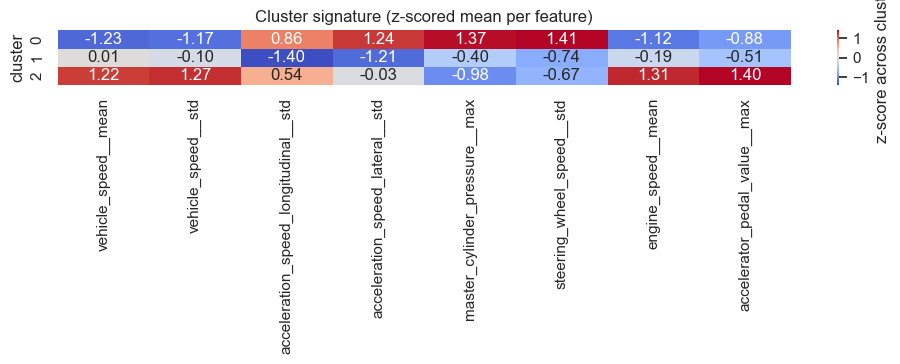

In [12]:
# Standardize the profile rows so each feature is comparable visually.
prof_z = (profile[profile_features] - profile[profile_features].mean()) / profile[profile_features].std(ddof=0)

fig, ax = plt.subplots(figsize=(10, 0.6 * best_k + 2))
sns.heatmap(prof_z, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "z-score across clusters"}, ax=ax)
ax.set_title("Cluster signature (z-scored mean per feature)")
ax.set_ylabel("cluster")
plt.tight_layout(); plt.show()


## 6. Per-driver cluster mix

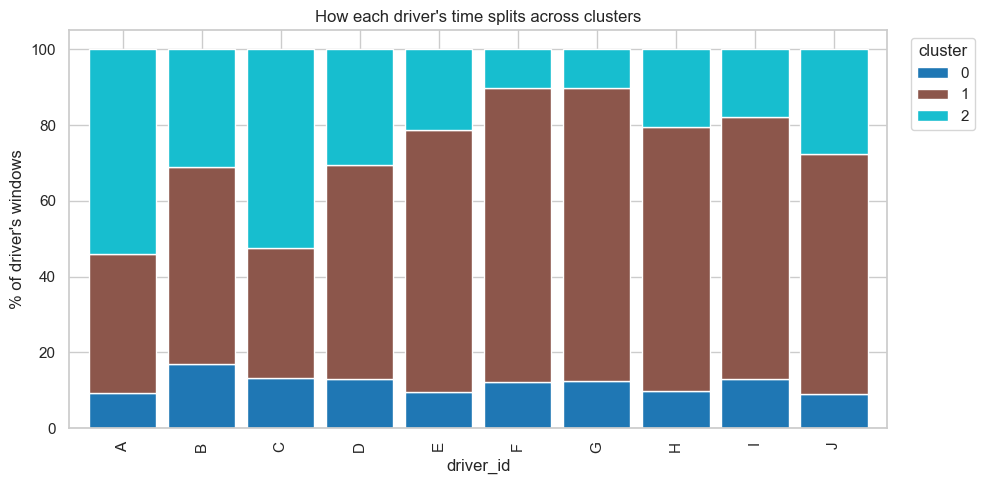

cluster,0,1,2
driver_id,,,
A,9.4,36.7,53.9
B,16.8,52.1,31.1
C,13.4,34.2,52.5
D,13.1,56.4,30.6
E,9.5,69.2,21.2
F,12.3,77.5,10.2
G,12.5,77.2,10.3
H,9.9,69.6,20.5
I,12.9,69.3,17.8


In [13]:
mix = (windows.groupby(["driver_id", "cluster"]).size()
                  .unstack(fill_value=0))
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
mix_pct.plot.bar(stacked=True, ax=ax, colormap="tab10", edgecolor="white", width=0.85)
ax.set_ylabel("% of driver's windows")
ax.set_title("How each driver's time splits across clusters")
ax.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
mix_pct.round(1)


## 7. Save artefacts

We save the per-window cluster labels next to the rest of the analysis
outputs so that later notebooks can reuse them.


In [14]:
OUT = ROOT / "reports" / "outputs" / "windows_kmeans.csv"
OUT.parent.mkdir(parents=True, exist_ok=True)
windows[["driver_id", "window_id", "global_window_id", "cluster"]].to_csv(OUT, index=False)
print("saved:", OUT.relative_to(ROOT))


saved: reports\outputs\windows_kmeans.csv
